---
# Metody probabilistyczne
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score, confusion_matrix

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.8.0'

# Przykład - [SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection)

Tym razem zajmiemy się analizą danych tekstowych na przykładzie filtra spamu

## Załadowanie danych

In [3]:
sms = pd.read_csv('sms+spam+collection/SMSSpamCollection', 
                  delimiter='\t', header=None, names=['is_spam', 'text'])

### Kategorie
Czy na pewno są tylko dwie? Jaki jest ich rozkład?

In [4]:
sms['is_spam'].value_counts()

is_spam
ham     4825
spam     747
Name: count, dtype: int64

Podmieniamy klasy na binarne, ale traktując `spam` jako pozytywną

In [5]:
sms['is_spam'] = sms['is_spam'].map({'spam': 1, 'ham': 0}).astype('int8')

## Wstępna analiza danych (EDA, *explanatory data analysis*)

Rzut oka na podstawowe statystyki dotyczące danych wejściowych może być pomocne w dostosowaniu modelu i hiperparametrów.

### Rozkład długości tekstu dla każdej z kategorii

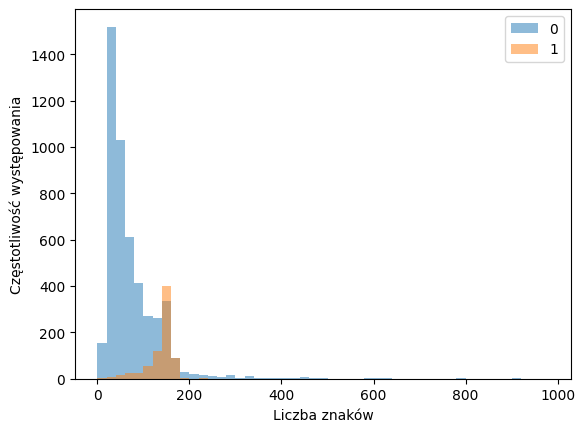

In [6]:
for cat in sms['is_spam'].unique():
    sms[sms['is_spam'] == cat]['text'].str.len().plot(bins=np.arange(0, 1000, 20), 
                                                      kind='hist', label=cat, alpha=0.5)
plt.xlabel('Liczba znaków')
plt.ylabel('Częstotliwość występowania')
# plt.yscale('log')
plt.legend();

Widać, że rozkłady długości dla obu kategorii są bardzo różne, ale nie możemy użyć tej statystyki do dobrego rozgraniczenia cech (chyba że intersuje nas wstępna filtracja danych).

## Wstępne przetwarzanie danych

### Podział na zbiór treningowy i testowy

Wyjątkowo robimy to teraz (por. poprzednie ćwiczenia), bo transformacja zależy od zbioru treningowego

In [7]:
X = sms['text']
y = sms['is_spam']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=0)

### Transformacja (wektoryzacja)

- Użyjemy wektoryzacji zliczeniowej (*count vectorization*)
- Wektoryzacja ta polega na skonstruowaniu macierzy zliczeń tokenów w tekście, co transformuje tekst w dane kategoryczne
- Poniżej używamy domyślnych parametrów oprócz usuwania mało isotnych słów (*stop words*) z języka angielskiego

In [9]:
vect = CountVectorizer(stop_words='english')

In [10]:
vect.fit(X_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [11]:
X_train_scaled     = vect.transform(X_train)
X_test_scaled      = vect.transform(X_test)
X_train_scaled_inv = vect.inverse_transform(X_train_scaled)
X_test_scaled_inv  = vect.inverse_transform(X_test_scaled)

#### Przykład

Zobaczmy, jak ta wektoryzacja działa w praktyce

In [12]:
idx = 100

Tekst orginalny

In [13]:
X_train.iloc[idx]

'Night night, see you tomorrow'

Tekst zakodowany 
- domyślnie to macierz rzadka
- poniżej wyświetlamy wartości na niezerowych pozycjach

In [14]:
nonzero_args = np.nonzero(X_train_scaled[idx].todense())
X_train_scaled[idx].todense()[nonzero_args]

matrix([[2, 1]])

Tekst odkodowany

In [15]:
X_train_scaled_inv[idx]

array(['night', 'tomorrow'], dtype='<U34')

## Naiwny klasyfikator Bayesa

Jako *baseline* użyjemy naiwnego klasyfikatora Bayesa z wielomianowym modelowaniem wiarygodności (*likelihood*), który jest zalecany do macierzy zliczeń

In [16]:
nbc = MultinomialNB()

### Dostrajamy model

In [17]:
nbc.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Sprawdzamy wyniki

In [18]:
y_train_pred = nbc.predict(X_train_scaled)
y_test_pred = nbc.predict(X_test_scaled)

In [19]:
roc_auc_score(y_train, y_train_pred), roc_auc_score(y_test, y_test_pred)

(0.9914970953536926, 0.9382946350410606)

In [20]:
confusion_matrix(y_train, y_train_pred)

array([[3845,   14],
       [   8,  590]])

In [21]:
confusion_matrix(y_test, y_test_pred)

array([[957,   9],
       [ 17, 132]])

Istotnie, wyniki są bardzo obiecujące!